# Exploring diagnostic diagrams based on spatially resolved models

The effect of resolved observations, as the ones obtained by IFUs or 3D spectroscopy, is explored. Photoioniozation models are run using Cloiudy, to reproduce the distribution of the different line emissivities, relative to the distance to the ionizing source. For each Cloudy model, a 2D slice going through the centrer of the model is produced and the projection on a 1D vector is obtained, as if it were seen edge-on. The vectors corresponding to different emission lines corresponds to what is observed in the plane of the sky, when observing an HII region with enough spatial resolution. Each pixel of the model 1D vector correspond to an observed spaxel. Line ratios are then obtained and placed in diagnostic diagram, where each nebula is then a series of points, a line connecting the modeled spaxels.

The models correspond to chemically homogeneous nebulae: there is no abundance gradients in the modeled HII regions.

This can be seen as a follow-up of the presentation at the "Waking the Line" 2018 workshop: https://zenodo.org/records/1206115

## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

The file WN2D_helper contains the functions needed to run, read and plot the Cloudy models

In [3]:
%load_ext autoreload
%aimport WN2D_helper
%autoreload 1

from WN2D_helper import make_grid, model_grid, l_dict, dir_models

## Define the models used

The models are obtained using:

* BPASS (binary) evolutionnary models as ionizing SED
* X/H vs. O/H determined by Nicholls paper + depletion
* log(U) vs. O/H decreasing law
* nH = 10 cm-3, filling factor = 1.0
* Dust following O/H
* Inner radius ~ 0.3 R_str to have a spatial ionization structure

$$Q_0 = \frac{4 . \pi . c^3 . U^3}{3 . n_H . ff^2 . \alpha_B^2 . ((1 + fr^3)^{1/3} - fr)^3}$$
$$R_{Str} = \left[\frac{3 . Q_0}{4 . \pi . n_H^2 . \alpha_B . ff}\right]^{1/3}$$
$$R_{in} = fr . R_{Str}$$

## Run the models if necesarry

In [4]:
dir_models = './models/'
name = 'M2_2My_'
#make_grid(name='M1_2My_', log_OH_min=-4.5, log_OH_max=-3.0, n_points=13, age=2, n_proc=10, fr=.3, NH=100, ff=0.1, ksi_d=0.35) # 18 mins on macbook

#make_grid(name='M2_2My_', log_OH_min=-4.5, log_OH_max=-3.0, n_points=13, age=2, n_proc=10, fr=.1, NH=100, ff=0.1, ksi_d=0.35, run=False) # 18 mins on macbook

## Read the models in the object and perform the integrations

* `cut` in [0,1], is to explore matter-bounded models
* `limit`[~0.05] is the Halpha fraction of intentity used to exclude spaxels


In [5]:
M3D = model_grid(name, dims=100, cut=None, limit=0.05, dir_models=dir_models)

In [6]:
M = M3D.Ms[5]

In [7]:
M.print_stats()

 Name of the model: ./models/M2_2My_-3.9
 R_in (cut) = 3.034e+18 (3.034e+18), R_out (cut) = 1.436e+19 (1.436e+19)
 Depth_in (cut) = 0.000e+00 (7.356e+13), depth_out (cut) = 1.133e+19 (1.132e+19)
 H+ mass = 9.81e+02, H mass = 1.03e+03 N zones: 190
 <H+/H> = 0.98, <He++/He> = 0.00, <He+/He> = 0.99
 <O+++/O> = 0.00, <O++/O> = 0.84, <O+/O> = 0.14
 <N+++/N> = 0.06, <N++/N> = 0.80, <N+/N> = 0.13
 T(O+++) = 15127, T(O++) = 13425, T(O+) = 13185
 <ne> = 103,  <nH> = 100, T0 = 13350, t2=0.0021
 <log U> = -2.03


## Plot the relations: log(U) vs. O/H and N/O vs. O/H, and the BPT

The models do not stricktly follow the KKS curves, but this is not crucial for the purpose treated here.

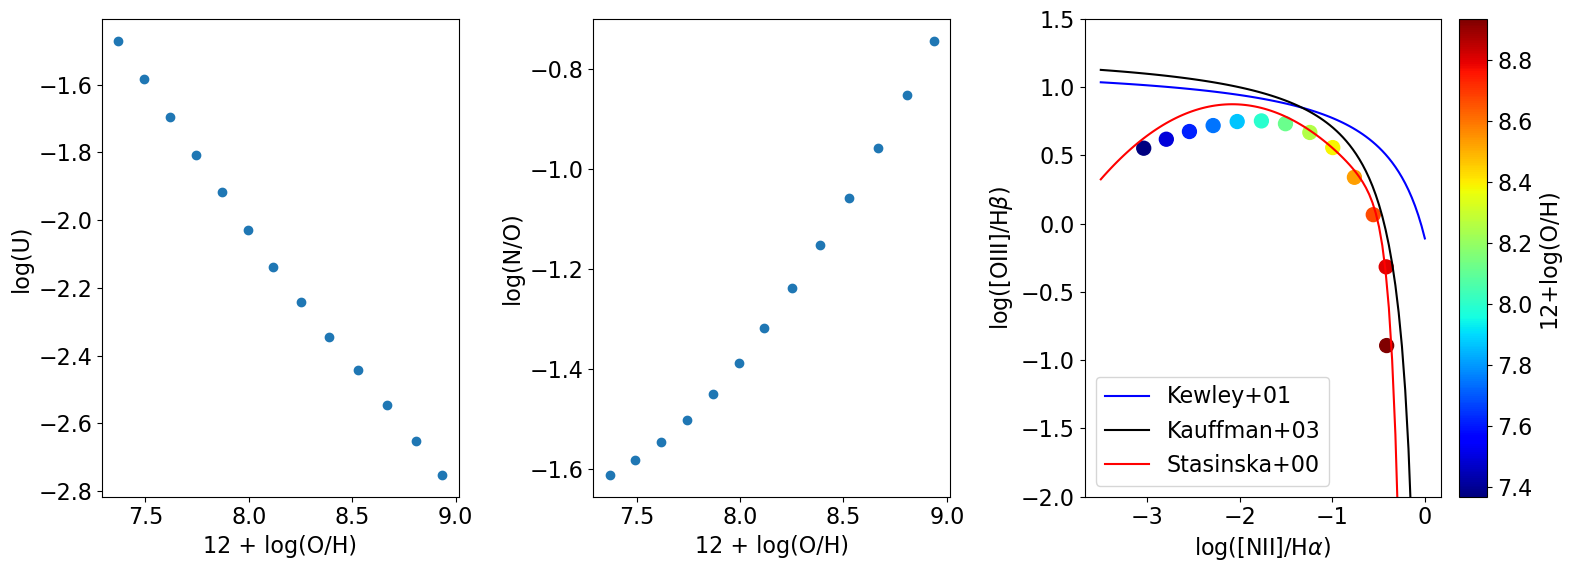

In [8]:
M3D.plot_I1()

## Draw the radial variation of the line emissions. 

This is a cut going through the central star (in the lower left corner), not an integration on the line of sight.

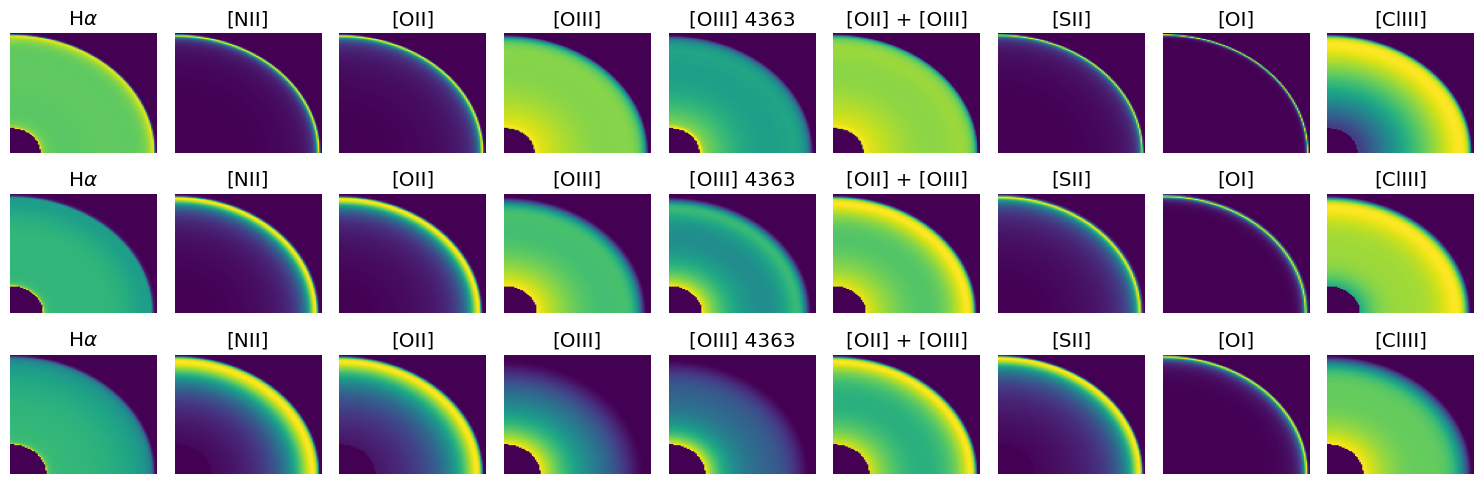

In [9]:
matplotlib.rcParams.update({'font.size': 12})
#f, axes = plt.subplots(len(M3D.Maps.keys()), 3, figsize=(5., 20.))
#for i, k in enumerate(M3D.Maps.keys()):
line_list = ['Has', 'N2s', 'O2s', 'O3s', 'O3as', 'R23s', 'S2s', 'O1s', 'Cl3s']
f, axes = plt.subplots(3, len(line_list), figsize=(15., 5.))
for i, k in enumerate(line_list):
    axes[0, i].imshow(M3D.Maps[k][3,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[0, i].set_title(l_dict[k])
    axes[0, i].set_axis_off()
    axes[1, i].imshow(M3D.Maps[k][7,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[1, i].set_title(l_dict[k])
    axes[1, i].set_axis_off()
    axes[2, i].imshow(M3D.Maps[k][10,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[2, i].set_title(l_dict[k])
    axes[2, i].set_axis_off()
f.tight_layout()
matplotlib.rcParams.update({'font.size': 16})

In [10]:
for i in (3, 7, 10):
    print(f'{i} : {M3D.Ms[i].model_name_s}: 12 + log(O/H) = {12+M3D.Ms[i].abund["O"]:.2f}')

3 : M2_2My_-4.1: 12 + log(O/H) = 7.74
7 : M2_2My_-3.6: 12 + log(O/H) = 8.25
10 : M2_2My_-3.2: 12 + log(O/H) = 8.67


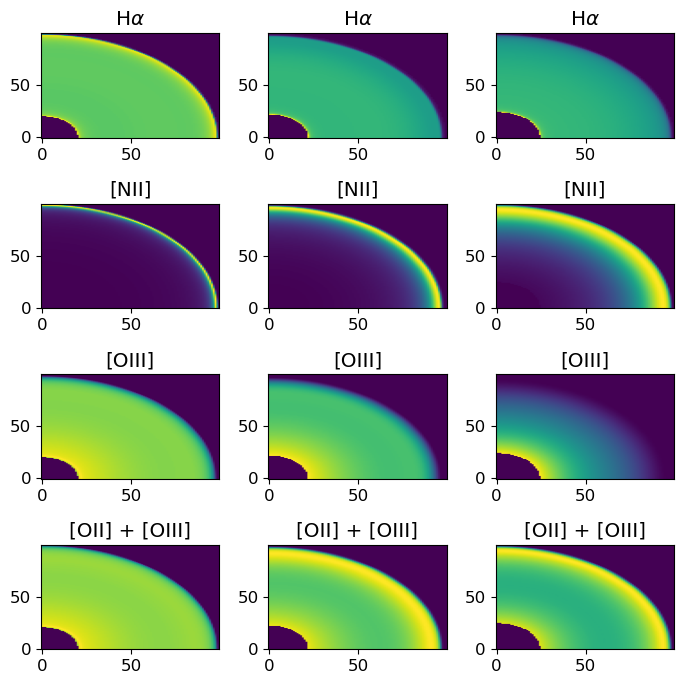

In [11]:
matplotlib.rcParams.update({'font.size': 12})
f, axes = plt.subplots(4, 3, figsize=(7., 7))
for i, k in enumerate(['Has', 'N2s', 'O3s', 'R23s']):
    axes[i, 0].imshow(M3D.Maps[k][3,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[i, 0].set_title(l_dict[k])
    axes[i, 1].imshow(M3D.Maps[k][7,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[i, 1].set_title(l_dict[k])
    axes[i, 2].imshow(M3D.Maps[k][10,:,:], origin='lower', aspect='auto', cmap='viridis')
    axes[i, 2].set_title(l_dict[k])
f.tight_layout()
matplotlib.rcParams.update({'font.size': 16})

In [12]:
M3D.I2.keys()

dict_keys(['Has', 'Hbs', 'N2s', 'N2as', 'O2s', 'O3s', 'O3as', 'R23s', 'S2s', 'S3s', 'Ar3s', 'pR2s', 'pN2s', 'pS2s', 'pR3s', 'O1s', 'Cl3s', 'N2S2Ha', 'x', 'OHs', '12OHs', 'TOpp', 'TOpp_PN', 'Opp', 'Opp_PN', 'Clpp', 'Clpp_PN', 'TNp', 'TNp_PN', 'Np', 'Np_PN', 'Op', 'Op_PN', 'NpOp', 'ClppOpp', 'pOH_RU', 'pOH_RL', 'pOH_R', 'pOH_SU', 'pOH_SL', 'pOH_S'])

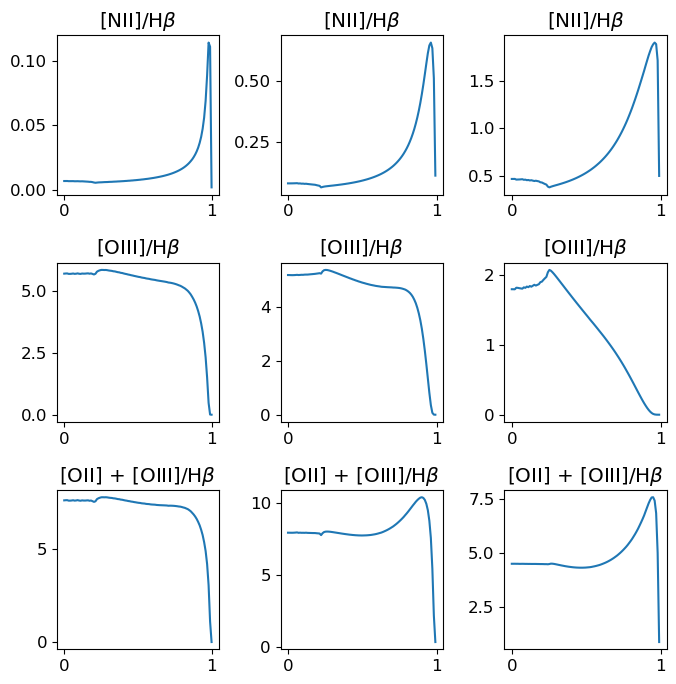

In [13]:
matplotlib.rcParams.update({'font.size': 12})
f, axes = plt.subplots(3, 3, figsize=(7., 7))
for i, k in enumerate(['N2s', 'O3s', 'R23s']):
    axes[i, 0].plot(M3D.I2['x'][3], M3D.I2[k][3] / M3D.I2['Hbs'][3])
    axes[i, 0].set_title(rf'{l_dict[k]}/H$\beta$')
    axes[i, 1].plot(M3D.I2['x'][7], M3D.I2[k][7] / M3D.I2['Hbs'][7])
    axes[i, 1].set_title(rf'{l_dict[k]}/H$\beta$')
    axes[i, 2].plot(M3D.I2['x'][10], M3D.I2[k][10] / M3D.I2['Hbs'][10])
    axes[i, 2].set_title(rf'{l_dict[k]}/H$\beta$')
f.tight_layout()
matplotlib.rcParams.update({'font.size': 16})

## Physical parameter from integrated nebulae

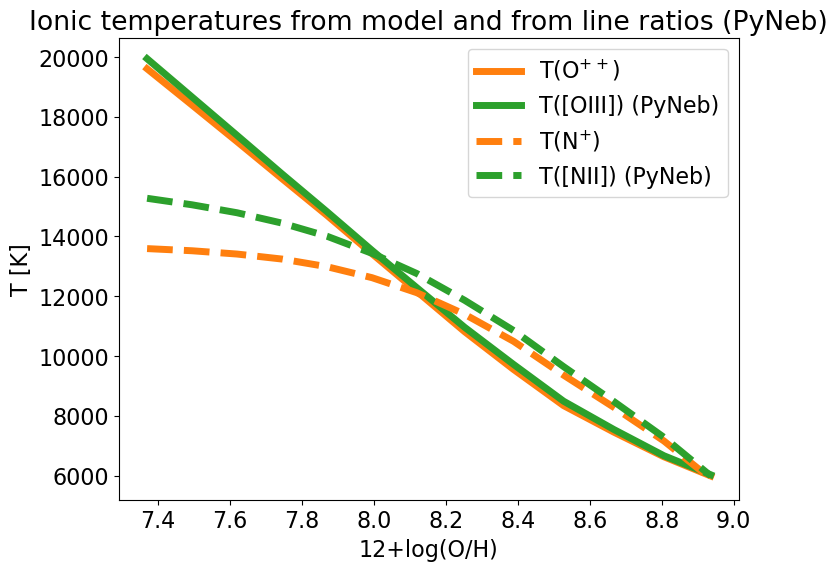

In [14]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(12+M3D.I1['OHs'], M3D.I1['TOpp'], label=r'T(O$^{++}$)', c='C1', lw=5)
ax.plot(12+M3D.I1['OHs'], M3D.I1['TOpp_PN'], label=r'T([OIII]) (PyNeb)', c='C2', lw=5)
ax.plot(12+M3D.I1['OHs'], M3D.I1['TNp'], label=r'T(N$^{+}$)', c='C1', ls='--', lw=5)
ax.plot(12+M3D.I1['OHs'], M3D.I1['TNp_PN'], label=r'T([NII]) (PyNeb)', c='C2', ls='--', lw=5)
ax.set_xlabel(r'12+log(O/H)')
ax.set_ylabel(r'T [K]')
ax.legend()
ax.set_title('Ionic temperatures from model and from line ratios (PyNeb)');

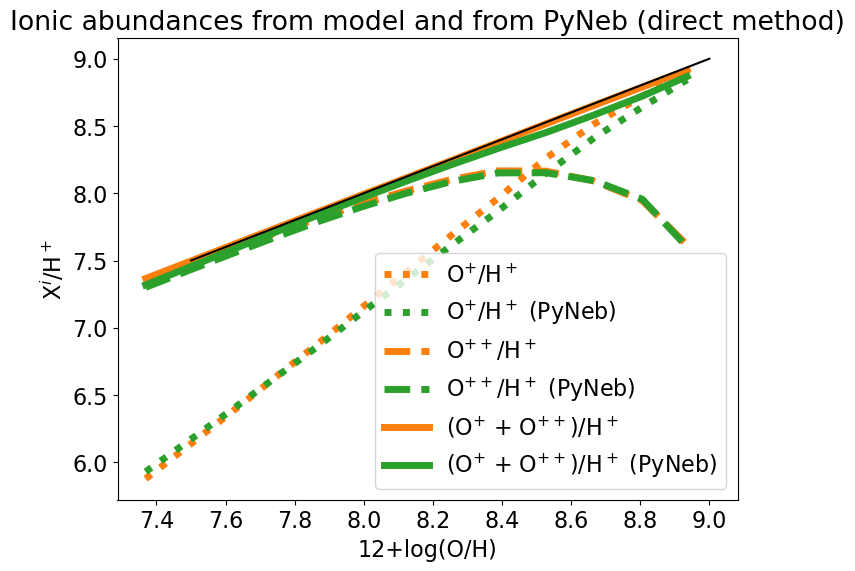

In [15]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Op']), label=r'O$^{+}$/H$^+$', c='C1', ls=':', lw=5)
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Op_PN']), label=r'O$^{+}$/H$^+$ (PyNeb)', c='C2', ls=':', lw=5)
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Opp']), label=r'O$^{++}$/H$^+$', c='C1', ls='--', lw=5)
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Opp_PN']), label=r'O$^{++}$/H$^+$ (PyNeb)', c='C2', ls='--', lw=5)
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Op'] + M3D.I1['Opp']), label=r'(O$^{+}$ + O$^{++}$)/H$^+$', c='C1', lw=5)
ax.plot(12+M3D.I1['OHs'], 12+np.log10(M3D.I1['Op_PN'] + M3D.I1['Opp_PN']), label=r'(O$^{+}$ + O$^{++}$)/H$^+$ (PyNeb)', c='C2', lw=5)
ax.plot((7.5, 9.0), (7.5, 9.0), c='k')
ax.set_xlabel(r'12+log(O/H)')
ax.set_ylabel(r'X$^i$/H$^+$')
ax.legend()
ax.set_title('Ionic abundances from model and from PyNeb (direct method)');

## Physical parameter from resolved nebulae

One model is chosen to explore the effects of the resolved observations:

In [16]:
i = 7

In [17]:
print(f'12 + log(O/H) = {12+M3D.Ms[i].abund["O"]:.2f}')

12 + log(O/H) = 8.25


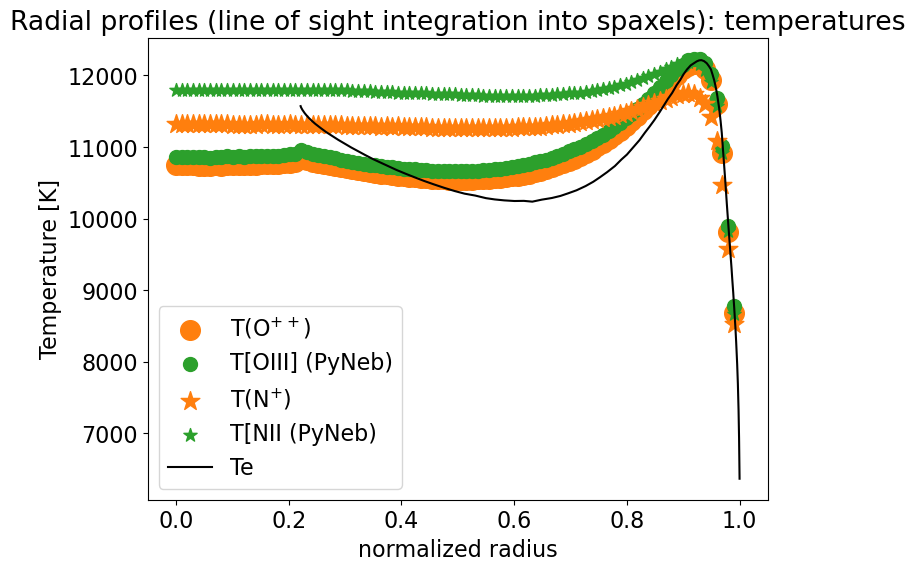

In [18]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
I2 = M3D.I2
ax.scatter(I2['x'][i], I2['TOpp'][i], label=r'T(O$^{++}$)', c='C1', marker='o', s=200)
ax.scatter(I2['x'][i], I2['TOpp_PN'][i], label='T[OIII] (PyNeb)', c='C2', marker='o', s=100)
ax.scatter(I2['x'][i], I2['TNp'][i], label=r'T(N$^{+}$)', c='C1', marker='*', s=200)
ax.scatter(I2['x'][i], I2['TNp_PN'][i], label=r'T[NII (PyNeb)', c='C2', marker='*', s=100)
ax.plot(M3D.Ms[i].radius/M3D.Ms[i].radius.max(), M3D.Ms[i].te, label=r'Te', c='k')
ax.set_xlabel('normalized radius')
ax.set_ylabel('Temperature [K]')
ax.legend()
ax.set_title('Radial profiles (line of sight integration into spaxels): temperatures');
#ax.set_ylim(11000, 13000);

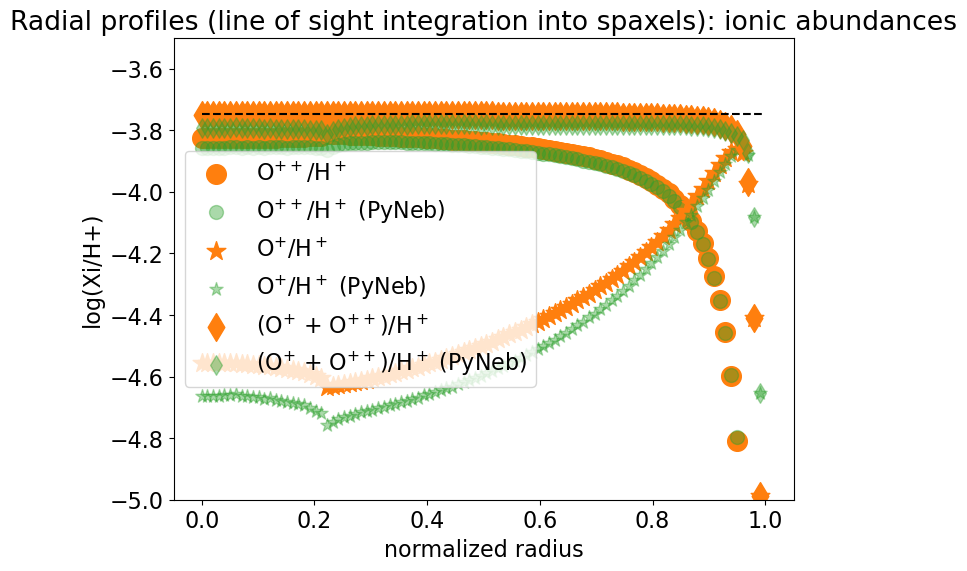

In [19]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(I2['x'][i], np.log10(I2['Opp'][i]), label=r'O$^{++}$/H$^+$', c='C1', marker='o', s=200)
ax.scatter(I2['x'][i], np.log10(I2['Opp_PN'][i]), label=r'O$^{++}$/H$^+$ (PyNeb)', c='C2', marker='o', s=100, alpha=0.4)
ax.scatter(I2['x'][i], np.log10(I2['Op'][i]), label=r'O$^{+}$/H$^+$', c='C1', marker='*', s=200)
ax.scatter(I2['x'][i], np.log10(I2['Op_PN'][i]), label=r'O$^{+}$/H$^+$ (PyNeb)', c='C2', marker='*', s=100, alpha=0.4)
ax.scatter(I2['x'][i], np.log10(I2['Op'][i] + I2['Opp'][i]), label=r'(O$^{+}$ + O$^{++}$)/H$^+$', c='C1', marker='d', s=200)
ax.scatter(I2['x'][i], np.log10(I2['Op_PN'][i] + I2['Opp_PN'][i]), label=r'(O$^{+}$ + O$^{++}$)/H$^+$ (PyNeb)', c='C2', marker='d', s=100, alpha=0.4)
ax.hlines(M3D.Ms[i].abund["O"], 0, 1, color='k', ls='--')
ax.set_xlabel('normalized radius')
ax.set_ylabel('log(Xi/H+)')
ax.legend()
ax.set_ylim(-5, -3.5)
ax.set_title('Radial profiles (line of sight integration into spaxels): ionic abundances');

## ICFs from resolved nebulae

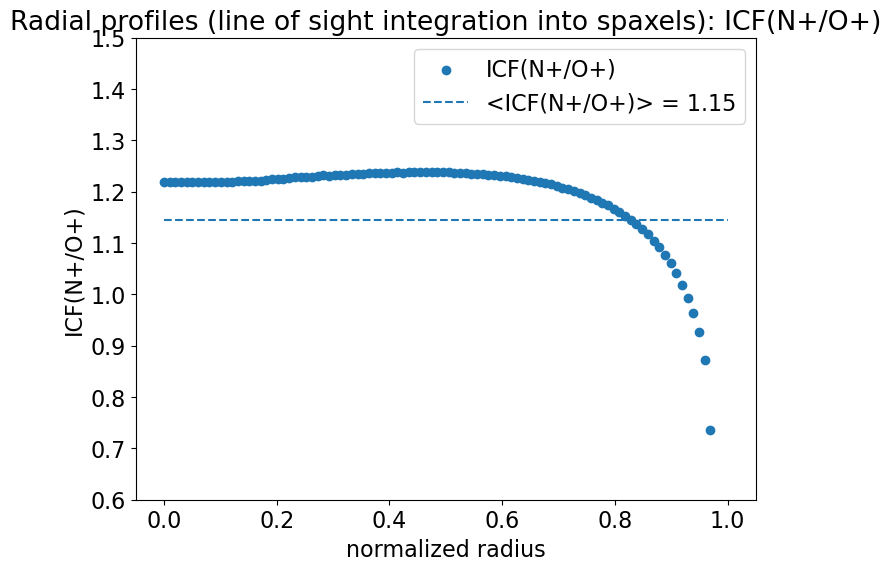

In [20]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(M3D.I2['x'][i], 1/M3D.I2['NpOp'][i], label='ICF(N+/O+)')
#w = M3D.I1['Opp'][i] / (M3D.I1['Op'][i] + M3D.I1['Opp'][i])
#w_PN = M3D.I2['Opp_PN'][i] / (M3D.I2['Op_PN'][i] + M3D.I2['Opp_PN'][i])
#ax.scatter(M3D.I2['x'][i], 10**(w_PN*0.64), label='ICF(N/O) DISM')
ax.hlines(1/M3D.I1["NpOp"][i], xmin=0, xmax=1, color='C0', linestyle='--', label=f'<ICF(N+/O+)> = {1/M3D.I1["NpOp"][i]:.2f}')
#ax.hlines(10**(w*0.64), xmin=0, xmax=1, color='C1', linestyle='--', label=f'ICF(N/O) = {10**(w*0.64):.2f}')
ax.set_xlabel('normalized radius')
ax.set_ylabel('ICF(N+/O+)')
ax.set_ylim(0.6, 1.5)
#ax.set_title(r'ICF(N+/O+) = 10**(0.64 * O$^{++}/(O^{+} + O^{++}))$')
ax.legend()
ax.set_title(r'Radial profiles (line of sight integration into spaxels): ICF(N+/O+)');

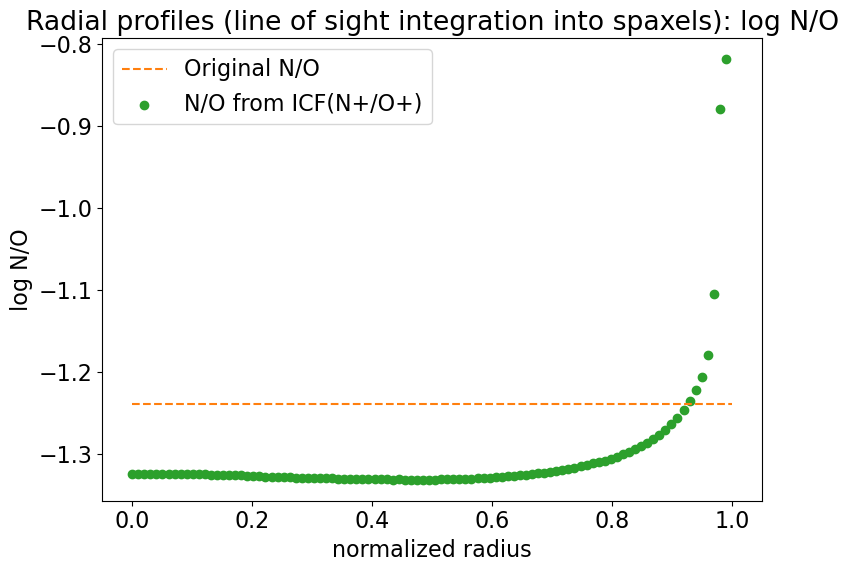

In [21]:
w = M3D.I1['Opp'][i] / (M3D.I1['Op'][i] + M3D.I1['Opp'][i])
w_PN = M3D.I2['Opp_PN'][i] / (M3D.I2['Op_PN'][i] + M3D.I2['Opp_PN'][i])
icf_21 = lambda w: 10**(-1.117 + 5.855*w -19.34*w**2 + 36.93 * w**3 -35.326*w**4 + 13.254*w**5)

f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hlines(M3D.Ms[i].abund['N'] - M3D.Ms[i].abund['O'], xmin=0, xmax=1, color='C1', linestyle='--', label='Original N/O')

ax.scatter(M3D.I2['x'][i], np.log10(M3D.I2['Np'][i] / M3D.I2['Op'][i]), label='N/O from ICF(N+/O+)', color='C2')

ax.set_xlabel('normalized radius')
ax.set_ylabel('log N/O')
#ax.set_ylim(-1.3, -0.9)
ax.legend();
ax.set_title(r'Radial profiles (line of sight integration into spaxels): log N/O');
f.tight_layout()

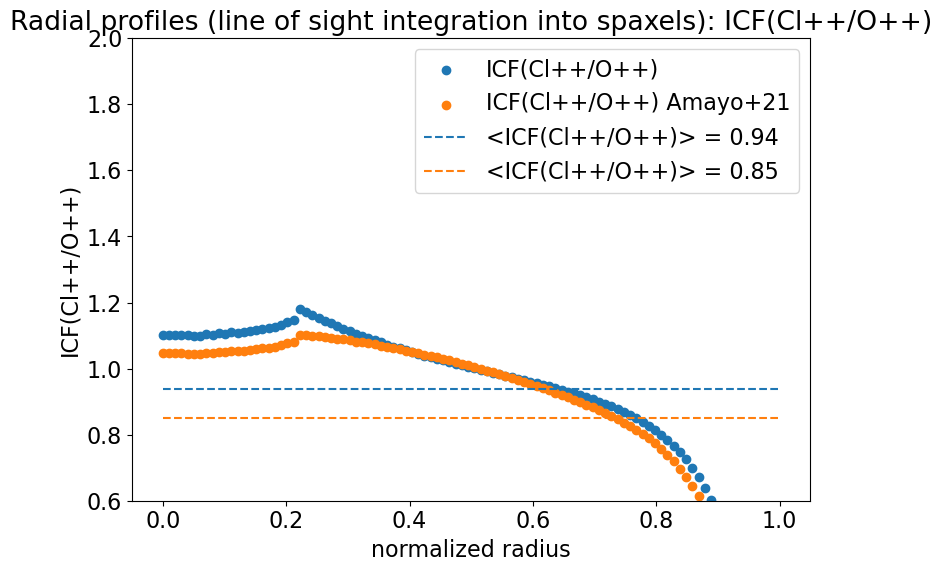

In [22]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(M3D.I2['x'][i], 1/M3D.I2['ClppOpp'][i], label='ICF(Cl++/O++)')
w = M3D.I1['Opp'][i] / (M3D.I1['Op'][i] + M3D.I1['Opp'][i])
w_PN = M3D.I2['Opp_PN'][i] / (M3D.I2['Op_PN'][i] + M3D.I2['Opp_PN'][i])
def icf_21(w):
    return 10**(-1.117 + 5.855*w -19.34*w**2 + 36.93 * w**3 -35.326*w**4 + 13.254*w**5)
ax.scatter(M3D.I2['x'][i], icf_21(w_PN), label='ICF(Cl++/O++) Amayo+21')
ax.hlines(1/M3D.I1["ClppOpp"][i], xmin=0, xmax=1, color='C0', linestyle='--', label=f'<ICF(Cl++/O++)> = {1/M3D.I1["ClppOpp"][i]:.2f}')
ax.hlines(icf_21(w), xmin=0, xmax=1, color='C1', linestyle='--', label=f'<ICF(Cl++/O++)> = {icf_21(w):.2f}')
ax.set_xlabel('normalized radius')
ax.set_ylabel('ICF(Cl++/O++)')
ax.set_ylim(0.6, 2.0)
ax.legend()
ax.set_title(r'Radial profiles (line of sight integration into spaxels): ICF(Cl++/O++)')
f.tight_layout();

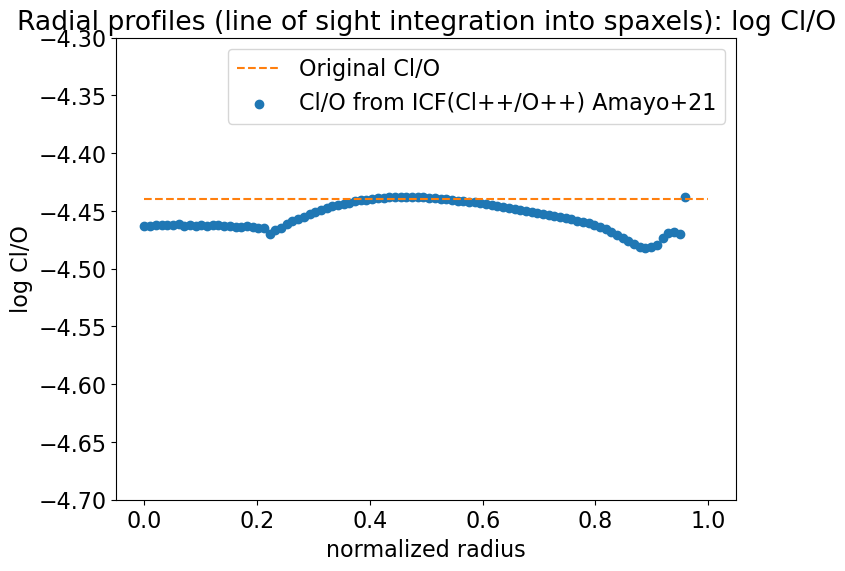

In [23]:
w = M3D.I1['Opp'][i] / (M3D.I1['Op'][i] + M3D.I1['Opp'][i])
w_PN = M3D.I2['Opp_PN'][i] / (M3D.I2['Op_PN'][i] + M3D.I2['Opp_PN'][i])
icf_21 = lambda w: 10**(-1.117 + 5.855*w -19.34*w**2 + 36.93 * w**3 -35.326*w**4 + 13.254*w**5)

f, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hlines(M3D.Ms[i].abund['Cl'] - M3D.Ms[i].abund['O'], xmin=0, xmax=1, color='C1', linestyle='--', label='Original Cl/O')

ax.scatter(M3D.I2['x'][i], np.log10(icf_21(w_PN)  * M3D.I2['Clpp'][i] / M3D.I2['Opp'][i]), label='Cl/O from ICF(Cl++/O++) Amayo+21')

ax.set_xlabel('normalized radius')
ax.set_ylabel('log Cl/O')
ax.set_ylim(-4.7, -4.3)
ax.legend();
ax.set_title(r'Radial profiles (line of sight integration into spaxels): log Cl/O');

## Plotting the resolved spaxels of the models into different diagrams

In the following, the locations in BPT diagrams of the different spaxels of the serie of models is shown. Each model corresponds to a given metallicity. The sizes of the dots increases with the distance to the central source of photoionization.

Text(0, 0.5, 'log([OIII]/H$\\beta$)')

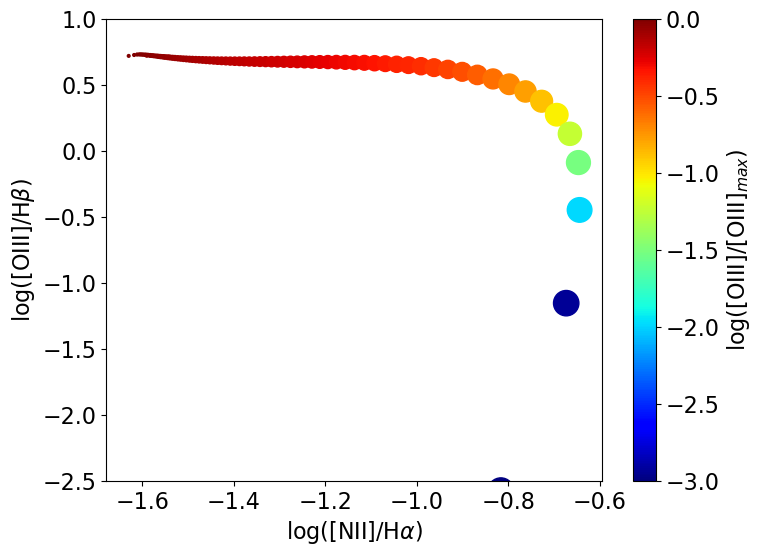

In [24]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
i = 7
x = np.log10(M3D.I2['N2s'][i,:] / M3D.I2['Has'][i,:])
y = np.log10(M3D.I2['O3s'][i,:] / M3D.I2['Hbs'][i,:])
s = 400 ** M3D.I2['x'][i]
c = np.log10(M3D.I2['O3s'][i,:] / np.max(M3D.I2['O3s'][i,:]))
sc = ax.scatter(x, y, s=s, c=c, cmap='jet', vmin=-3)
cb = f.colorbar(sc, ax=ax)
cb.set_label(r'log([OIII]/[OIII]$_{max}$)')
#ax.set_xlim(-2.5, -1)
ax.set_ylim(-2.5, 1.)
ax.set_xlabel(r'log([NII]/H$\alpha$)')
ax.set_ylabel(r'log([OIII]/H$\beta$)')

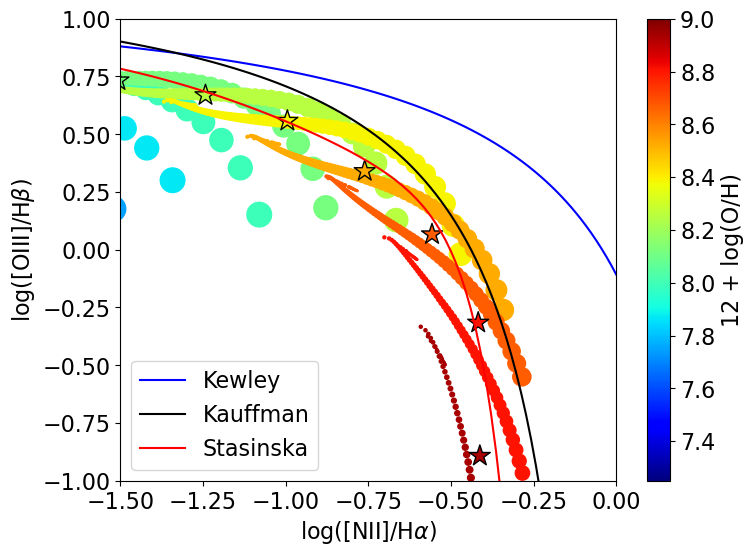

In [25]:
M3D.plot_BPT('N2s', 'Has', 'O3s', 'Hbs', xlim=(-1.5, 0.), ylim=(-1., 1.0), plot_KKS=True, vmin=7.25, vmax=9.0)

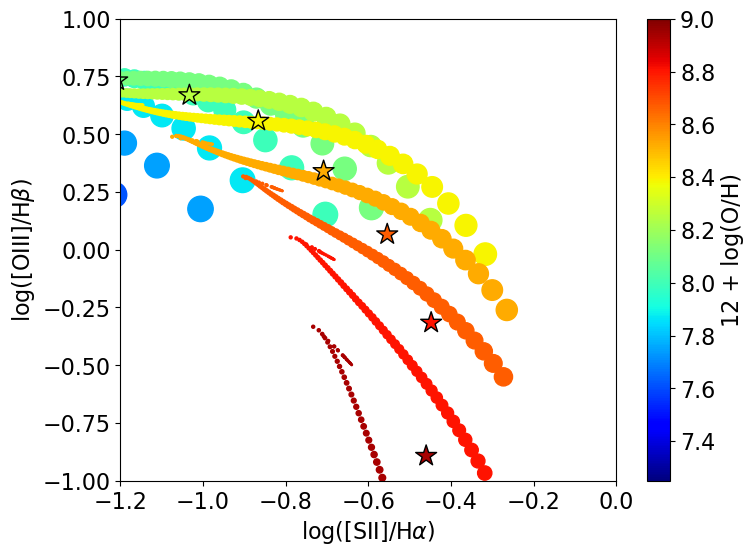

In [26]:
M3D.plot_BPT('S2s', 'Has', 'O3s', 'Hbs', xlim=(-1.2, 0.), ylim=(-1., 1.), vmin=7.25, vmax=9.0)

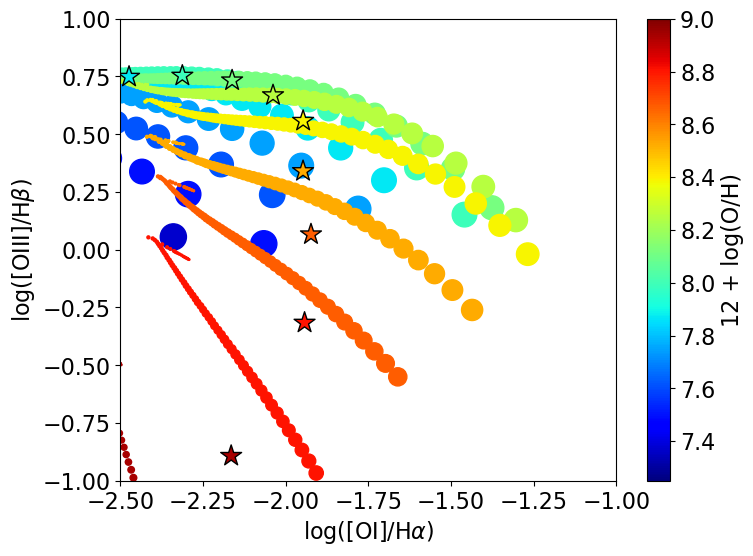

In [27]:
M3D.plot_BPT('O1s', 'Has', 'O3s', 'Hbs', xlim=(-2.5, -1.), ylim=(-1., 1.0), vmin=7.25, vmax=9.0)

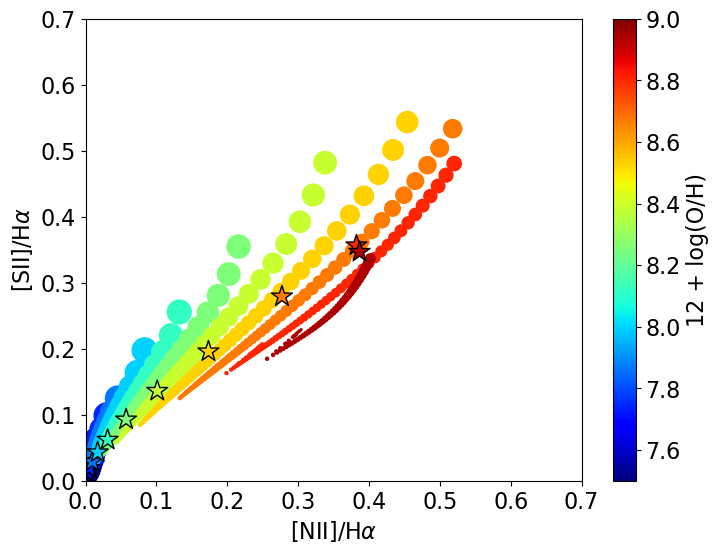

In [28]:
M3D.plot_BPT('N2s', 'Has', 'S2s', 'Has', xlim=(0, 0.7), ylim=(0, 0.7), xlog=False, ylog=False, vmin=7.5, vmax=9.0)

## Explore the strong line calibration using spaxels

It is also possible to draw the traces of the models in diagrams where the O/H abundance is plotted relative to a given strong line diagnostic. It is then easy to see that an _apparent_ gradient in metallicity can be derived using a simple relation between strong line and O/H, while chemically homogeneous models have been obtained considered. 

Marino's relations are overplotted as a black line.

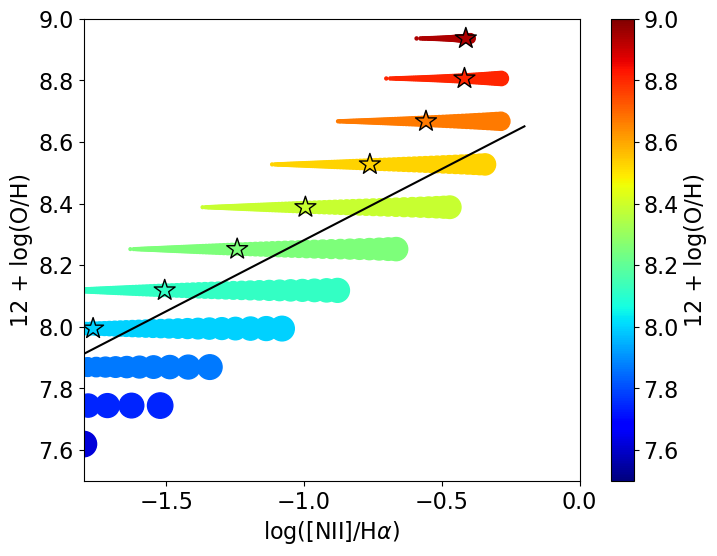

In [29]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('N2s', 'Has', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 0.0), ylog=False, ax=ax)
x_tab = np.linspace(-1.8, -0.2, 100)
y_tab = 8.743 + 0.462*x_tab
ax.plot(x_tab, y_tab, c='k');

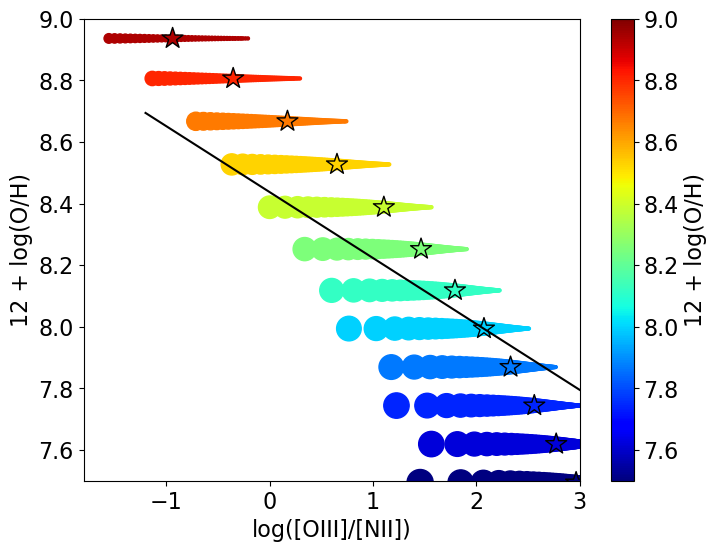

In [30]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('O3s', 'N2s', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 3.0), ylog=False, ax=ax)
x_tab = np.linspace(-1.2, 3, 100)
y_tab = 8.533 - 0.214 * (x_tab + np.log10(2.8))
ax.plot(x_tab, y_tab, c='k');

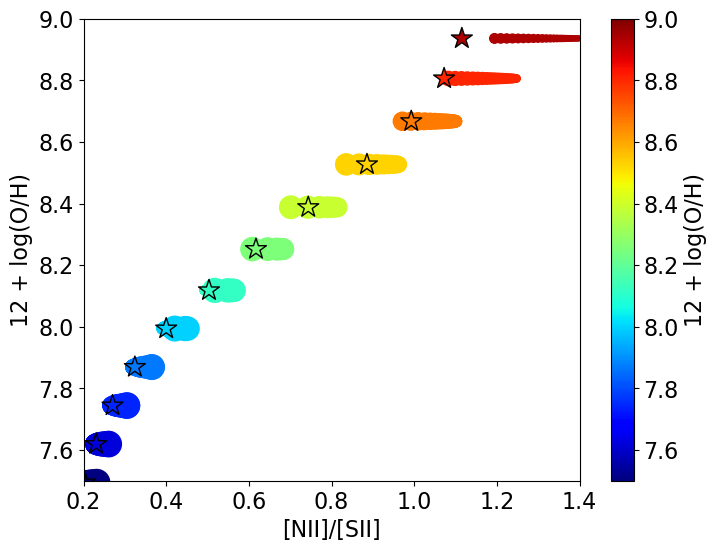

In [31]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('N2s', 'S2s', '12OHs', None, ylim=(7.5, 9), xlim=(0.2, 1.4), ylog=False, xlog=False, ax=ax)
f.savefig('N2S2_OH_calibration.pdf')

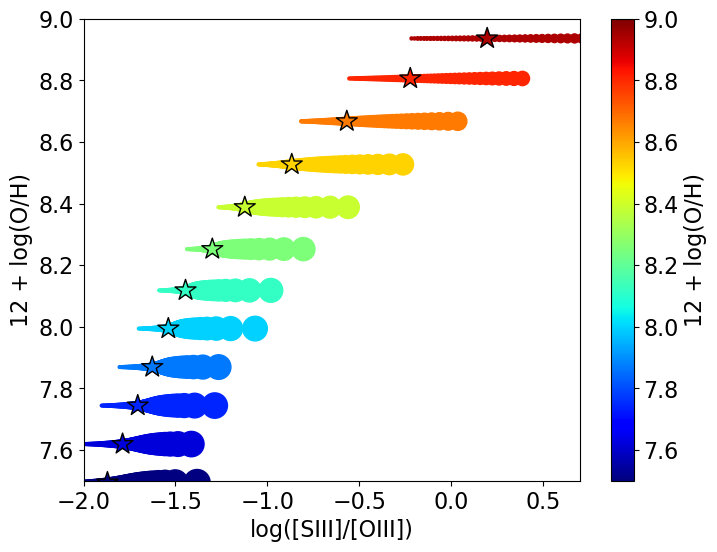

In [39]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('S3s', 'O3s', '12OHs', None, ylim=(7.5, 9), xlim=(-2, 0.7), ylog=False, xlog=True, ax=ax)
f.savefig('S3O3_OH_calibration.pdf')

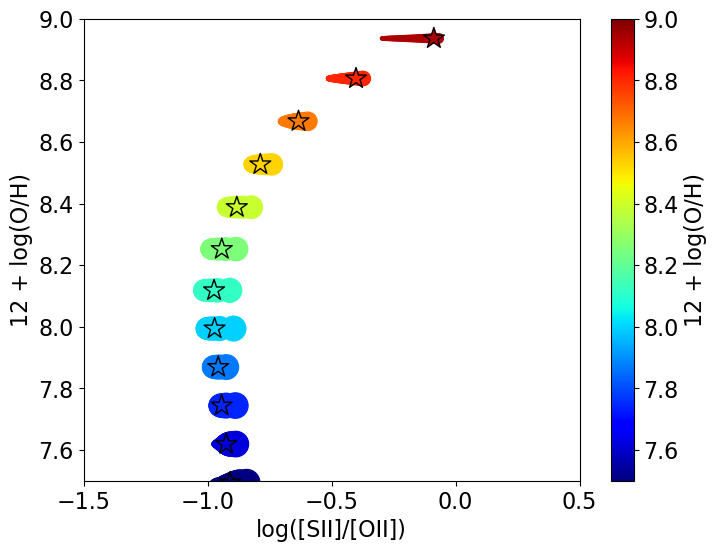

In [33]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('S2s', 'O2s', '12OHs', None, ylim=(7.5, 9), xlim=(-1.5, 0.5), ylog=False, ax=ax)

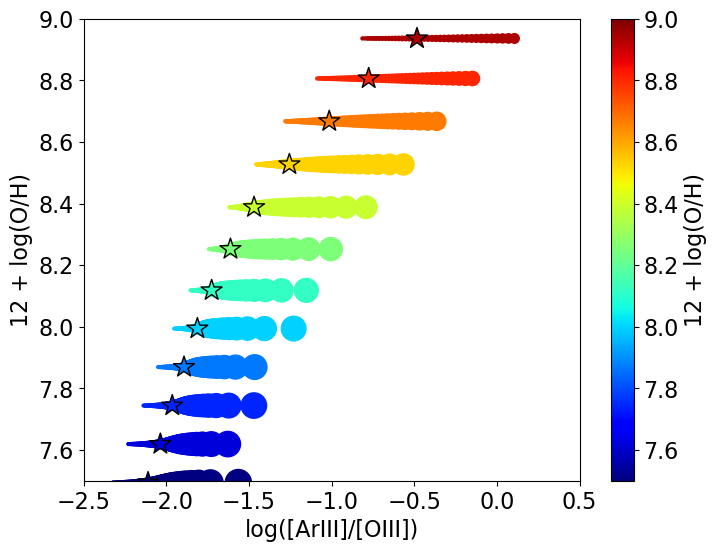

In [36]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('Ar3s', 'O3s', '12OHs', None, ylim=(7.5, 9), xlim=(-2.5, 0.5), ylog=False, ax=ax)

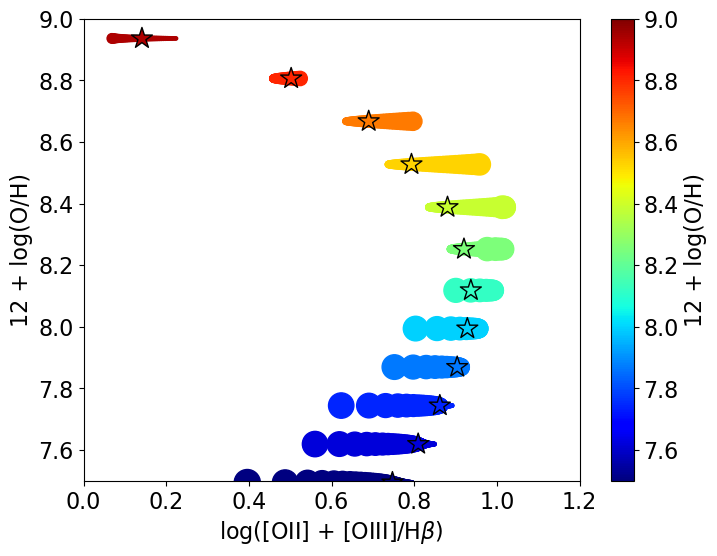

In [33]:
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('R23s', 'Hbs', '12OHs', None, ylim=(7.5, 9), xlim=(-0., 1.2), ylog=False, ax=ax)

### N2S2Ha diagram (Dopita+16)

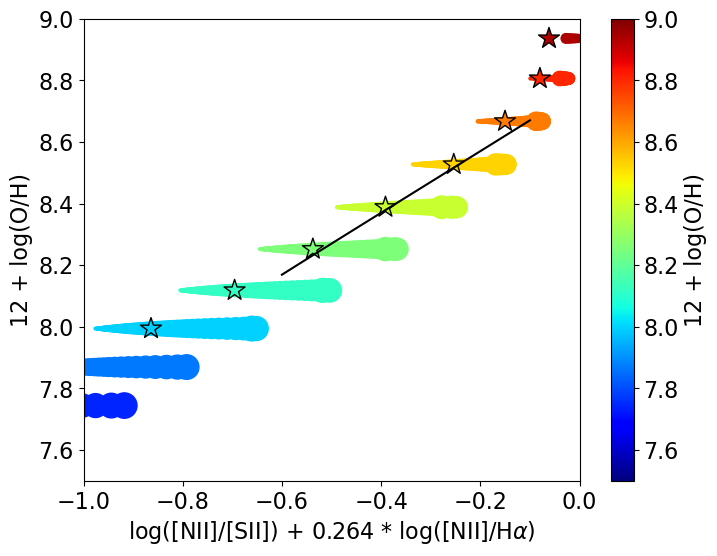

In [37]:
# Compare to Easeman+24
f, ax = plt.subplots(1, 1, figsize=(8, 6))
M3D.plot_BPT('N2S2Ha', None, '12OHs', None, ylim=(7.5, 9), xlim=(-0.6, -0.1), ylog=False, ax=ax)
x = np.linspace(-0.6, -0.1, 100)
y = 8.77 + x + 0.45 * (x + 0.3)**5
ax.plot(x, y, c='k')
ax.set_xlabel(r'log([NII]/[SII]) + 0.264 * log([NII]/H$\alpha$)')
ax.set_xlim(-1, 0.)
ax.set_ylim(7.5, 9)
f.savefig('N2S2Ha_OH_calibration.pdf')

### Pilyugin R and S 

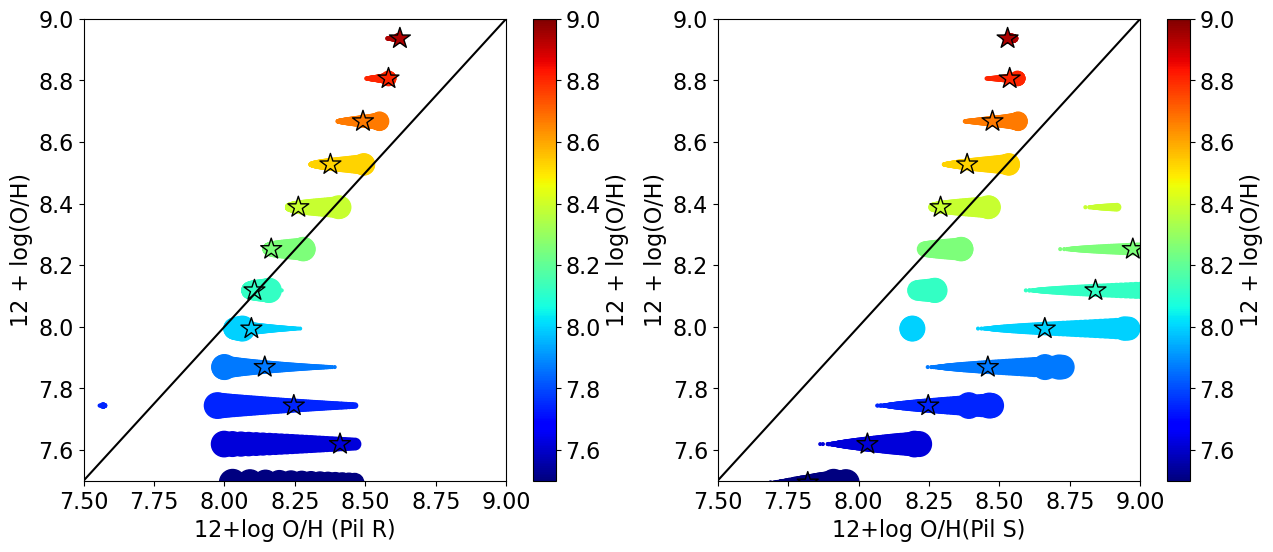

In [38]:
# Compare to Easeman+24
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
lims = (7.5, 9)
M3D.plot_BPT('pOH_R', None, '12OHs', None, ylim=lims, xlim=lims, xlog=False, ylog=False, ax=ax1)
M3D.plot_BPT('pOH_S', None, '12OHs', None, ylim=lims, xlim=lims, xlog=False, ylog=False, ax=ax2)
x = np.linspace(lims[0], lims[1], 10)
ax1.plot(x, x, c='k')
ax2.plot(x, x, c='k')
#ax.set_xlim(-0.5, 0.5)
for ax in (ax1, ax2):
    ax.set_xlim(7.5, 9.0)
    ax.set_ylim(7.5, 9.0)
f.savefig('PilRS_OH_calibration.pdf')

## Using matter-bounded models

Matter-bounded models are obtained from the same Cloudy models, by applying a cut corresponding to the radius at which Hbeta = cut * Hbeta_full

In [20]:
M3Dc = model_grid(name, dims=100, cut=0.5, limit=0.05, dir_models=dir_models)

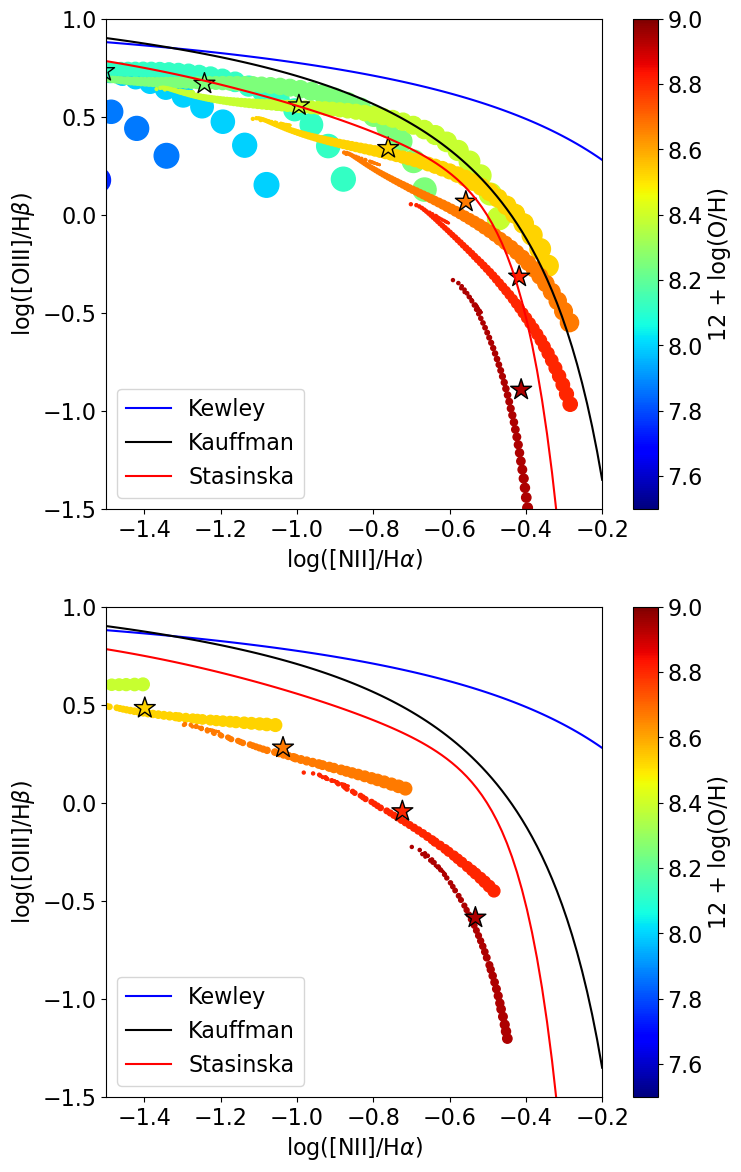

In [50]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 14))
M3D.plot_BPT('N2s', 'Has', 'O3s', 'Hbs', xlim=(-1.5, -0.2), ylim=(-1.5, 1.0), plot_KKS=True, ax=ax1, vmin=7.5, vmax=9.0)
M3Dc.plot_BPT('N2s', 'Has', 'O3s', 'Hbs', xlim=(-1.5, -0.2), ylim=(-1.5, 1.0), plot_KKS=True, ax=ax2, vmin=7.5, vmax=9.0)

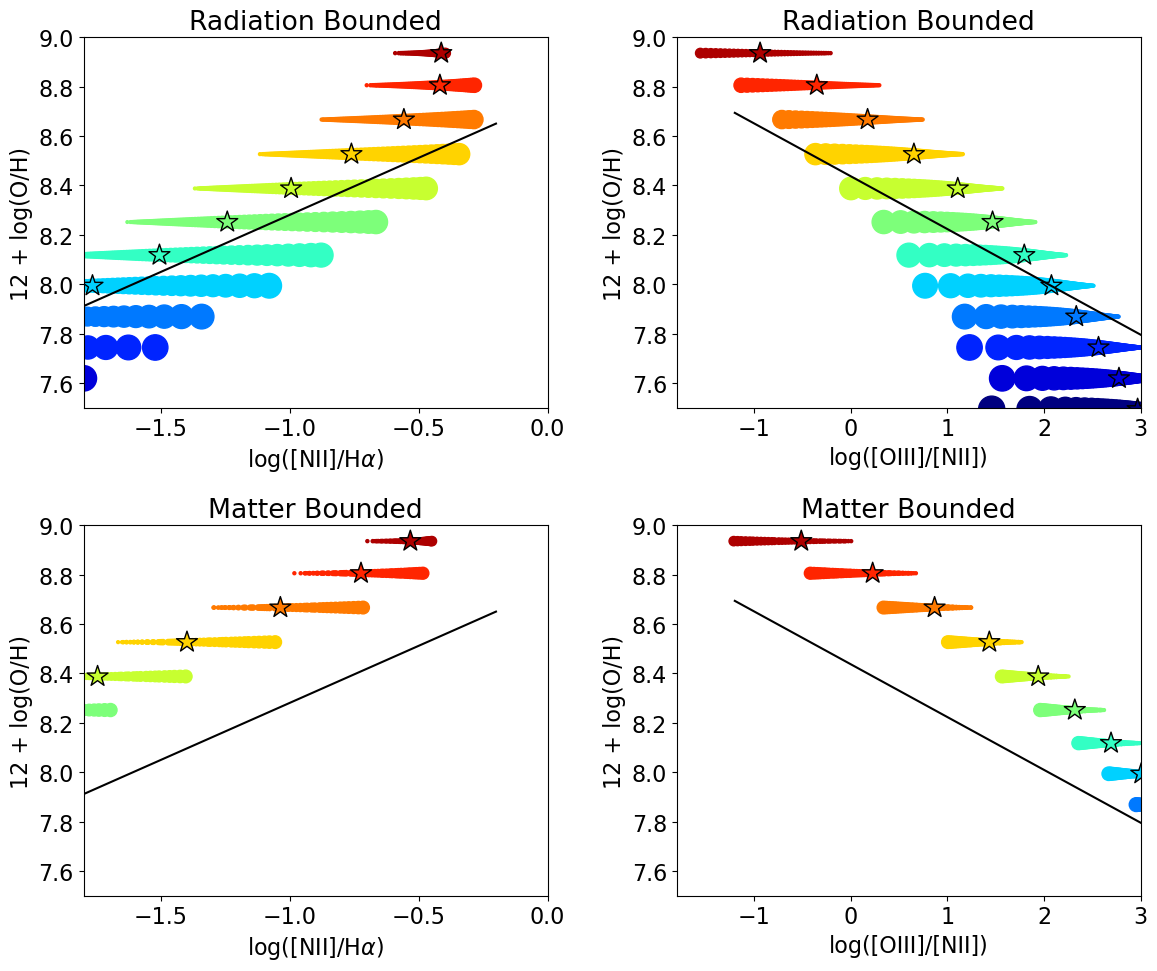

In [21]:
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
plot_cb = False
M3D.plot_BPT('N2s', 'Has', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 0.0), ylog=False, ax=ax1, plot_cb=plot_cb)
x_tab = np.linspace(-1.8, -0.2, 100)
y_tab = 8.743 + 0.462*x_tab
ax1.plot(x_tab, y_tab, c='k');
ax1.set_title('Radiation Bounded')
M3D.plot_BPT('O3s', 'N2s', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 3.0), ylog=False, ax=ax2, plot_cb=plot_cb)
x_tab = np.linspace(-1.2, 3, 100)
y_tab = 8.533 -0.214 * (x_tab + np.log10(2.8))
ax2.plot(x_tab, y_tab, c='k');
ax2.set_title('Radiation Bounded')

M3Dc.plot_BPT('N2s', 'Has', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 0.0), ylog=False, ax=ax3, plot_cb=plot_cb)
x_tab = np.linspace(-1.8, -0.2, 100)
y_tab = 8.743 + 0.462*x_tab
ax3.plot(x_tab, y_tab, c='k');
ax3.set_title('Matter Bounded')
M3Dc.plot_BPT('O3s', 'N2s', '12OHs', None, ylim=(7.5, 9), xlim=(-1.8, 3.0), ylog=False, ax=ax4, plot_cb=plot_cb)
x_tab = np.linspace(-1.2, 3, 100)
y_tab = 8.533 -0.214 * (x_tab + np.log10(2.8))
ax4.plot(x_tab, y_tab, c='k')
ax4.set_title('Matter Bounded')

f.tight_layout()


# Conclusions

* Physical parameters (Te, Ne) can be determined in spatially resolved observations, in each spaxel.
* Ionic abundances can also be determined in spaxels.
* Elemental abundances may be obtained using the previously determined ionic abundances (direct method using ICFs), but with caution.
* Abundances CAN NOT be determined using strong line calibrations: these methods are statistical and based on integrated objects, relaying on a relation between logU and O/H.
* Ionization source may be determined using the classical BPT OIII vs. NII, but with caution. Not from [SII].
* Matter-bounded regions add noise to the picture.